# Exploratory Data Analysis — Crypto Prediction Market Features

Preliminary EDA on `final_data.csv`, a cleaned second-level dataset combining Polymarket, Kalshi, Coinbase, and Deribit data across BTC, ETH, XRP, and SOL 15-minute prediction windows. Each row is a ~1-second snapshot. The targets are `next_price_dollars_lead1` (next-step Polymarket mid price) and `outcome` (binary resolution).

In [6]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 100, 'savefig.dpi': 150})

---
## 1. Data Overview

In [7]:
DATA_PATH = r'final_data/final_data.csv'

DATETIME_COLS = ['curr_time', 'open_time', 'close_time', 'prev_time']

df = pd.read_csv(DATA_PATH, parse_dates=DATETIME_COLS)
print(f'Shape: {df.shape[0]:,} rows × {df.shape[1]} columns')
df.dtypes

Shape: 1,017,826 rows × 54 columns


curr_time                        datetime64[ns, UTC]
open_time                        datetime64[ns, UTC]
close_time                       datetime64[ns, UTC]
prev_time                        datetime64[ns, UTC]
time_to_close                                  int64
last_price_dollars                           float64
yes_mid_dollars                              float64
yes_spread_dollars                           float64
distance_from_strike                         float64
yes_mid_change_1s                            float64
yes_mid_change_5s                            float64
yes_mid_change_std_30s                       float64
yes_mid_change_std_60s                       float64
yes_spread_mean_30s                          float64
next_price_dollars_lead1                     float64
outcome                                        int64
ETH_last_price_dollars                       float64
ETH_yes_mid_dollars                          float64
ETH_yes_spread_dollars                       f

In [8]:
df.head()

,curr_time,open_time,close_time,prev_time,time_to_close,last_price_dollars,yes_mid_dollars,yes_spread_dollars,distance_from_strike,yes_mid_change_1s,...,btc_spot_size_1s,btc_spot_signed_size_1s,btc_spot_return_1s,btc_spot_return_5s,btc_spot_return_15s,btc_spot_return_60s,btc_spot_return_vol_30s,btc_spot_return_vol_5m,btc_spot_signed_flow_mean_30s,btc_spot_size_mean_30s
0,2026-03-21 10:47:33.863137+00:00,2026-03-21 10:45:00+00:00,2026-03-21 11:00:00+00:00,2026-03-21 10:47:32.862397+00:00,746,0.41,0.41,0.02,-15.72,0.0,...,0.000141,-0.000141,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,2026-03-21 10:47:34.863913+00:00,2026-03-21 10:45:00+00:00,2026-03-21 11:00:00+00:00,2026-03-21 10:47:33.863137+00:00,745,0.41,0.41,0.02,-15.72,0.0,...,0.000511,-0.000511,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,2026-03-21 10:47:35.864626+00:00,2026-03-21 10:45:00+00:00,2026-03-21 11:00:00+00:00,2026-03-21 10:47:34.863913+00:00,744,0.41,0.41,0.02,-15.72,0.0,...,0.002754,-0.002754,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,2026-03-21 10:47:36.866221+00:00,2026-03-21 10:45:00+00:00,2026-03-21 11:00:00+00:00,2026-03-21 10:47:35.864626+00:00,743,0.41,0.41,0.02,-15.72,0.0,...,0.006444,-0.006444,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,2026-03-21 10:47:37.866620+00:00,2026-03-21 10:45:00+00:00,2026-03-21 11:00:00+00:00,2026-03-21 10:47:36.866221+00:00,742,0.41,0.41,0.02,-15.73,0.0,...,0.001234,-0.001234,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [9]:
df.describe()

,time_to_close,last_price_dollars,yes_mid_dollars,yes_spread_dollars,distance_from_strike,yes_mid_change_1s,yes_mid_change_5s,yes_mid_change_std_30s,yes_mid_change_std_60s,yes_spread_mean_30s,...,btc_spot_size_1s,btc_spot_signed_size_1s,btc_spot_return_1s,btc_spot_return_5s,btc_spot_return_15s,btc_spot_return_60s,btc_spot_return_vol_30s,btc_spot_return_vol_5m,btc_spot_signed_flow_mean_30s,btc_spot_size_mean_30s
count,1.017826e+06,1.017826e+06,1.017826e+06,1.017826e+06,1.017826e+06,1.017826e+06,1.017826e+06,1.017826e+06,1.017826e+06,1.017826e+06,...,1.017826e+06,1.017826e+06,1.017826e+06,1.017826e+06,1.017826e+06,1.017826e+06,1.017826e+06,1.017826e+06,1.017826e+06,1.017826e+06
mean,4.370539e+02,4.995167e-01,4.995972e-01,1.143412e-02,-8.790060e+00,3.925524e-06,2.197576e-05,1.019997e-02,1.110976e-02,1.152488e-02,...,9.625117e-02,-7.967610e-04,-2.842899e-07,-1.344494e-06,-3.570011e-06,-8.885204e-06,6.206275e-05,6.850236e-05,-5.792013e-04,9.929934e-02
std,2.527578e+02,3.095941e-01,3.100940e-01,1.004341e-02,1.351782e+02,1.664452e-02,3.650123e-02,1.289743e-02,1.152002e-02,8.170404e-03,...,4.706684e-01,4.316292e-01,7.626730e-05,1.821414e-04,3.260521e-04,6.672704e-04,4.717901e-05,4.061886e-05,9.627226e-02,1.576606e-01
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-1.578860e+03,-8.470000e-01,-8.470000e-01,0.000000e+00,0.000000e+00,0.000000e+00,...,1.000000e-08,-3.969509e+01,-1.016287e-02,-1.023316e-02,-1.072715e-02,-1.160888e-02,0.000000e+00,0.000000e+00,-2.418959e+00,0.000000e+00
25%,2.180000e+02,2.500000e-01,2.500000e-01,1.000000e-02,-6.109000e+01,0.000000e+00,0.000000e+00,1.825742e-03,2.867113e-03,1.000000e-02,...,3.539725e-04,-4.817667e-03,-3.003354e-07,-6.579627e-05,-1.436803e-04,-3.169897e-04,3.342373e-05,4.405673e-05,-2.129045e-02,2.118645e-02
50%,4.370000e+02,5.000000e-01,5.000000e-01,1.000000e-02,-6.650000e+00,0.000000e+00,0.000000e+00,5.933661e-03,8.334463e-03,1.000000e-02,...,3.323630e-03,-2.821850e-04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,5.139365e-05,5.875967e-05,-1.581288e-03,5.174181e-02
75%,6.560000e+02,7.500000e-01,7.500000e-01,1.000000e-02,4.575000e+01,0.000000e+00,0.000000e+00,1.460593e-02,1.563600e-02,1.366667e-02,...,4.129791e-02,3.882475e-04,1.957146e-06,6.473815e-05,1.389634e-04,3.062283e-04,7.792563e-05,8.109074e-05,1.595695e-02,1.151825e-01
max,8.970000e+02,9.990000e-01,9.995000e-01,7.690000e-01,2.958550e+03,8.375000e-01,8.375000e-01,2.244560e-01,1.582615e-01,4.740000e-01,...,6.156617e+01,6.094891e+01,2.778962e-03,6.749325e-03,1.005386e-02,2.298673e-02,1.856805e-03,8.831296e-04,3.406454e+00,5.319913e+00


### Missing values

In [10]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_report = pd.DataFrame({'count': missing, 'pct': missing_pct})
missing_report = missing_report[missing_report['count'] > 0].sort_values('pct', ascending=False)

if missing_report.empty:
    print('No missing values in any column.')
else:
    print(f'{len(missing_report)} columns with missing values:')
    display(missing_report)
    if len(missing_report) >= 3:
        cols_with_missing = missing_report.index.tolist()
        sample = df[cols_with_missing].sample(min(500, len(df)), random_state=42)
        fig, ax = plt.subplots(figsize=(max(10, len(cols_with_missing) * 0.5), 5))
        sns.heatmap(sample.isnull().T, cbar=False, yticklabels=True, ax=ax, cmap='Reds')
        ax.set_title('Missingness Heatmap (sample of 500 rows)')
        ax.set_xlabel('Row index')
        plt.tight_layout()
        plt.show()

1 columns with missing values:


,count,pct
next_price_dollars_lead1,1181,0.12


In [11]:
inf_counts = np.isinf(df.select_dtypes(include='number')).sum()
inf_report = inf_counts[inf_counts > 0]
if inf_report.empty:
    print('No infinite values in any numeric column.')
else:
    print('Columns with inf values:')
    display(inf_report)

No infinite values in any numeric column.


### 15-minute window statistics

Unique 15-min windows (open_time): 1,184
Date range: 2026-03-21 10:47:33.863137+00:00 → 2026-04-03 01:41:06.839613+00:00


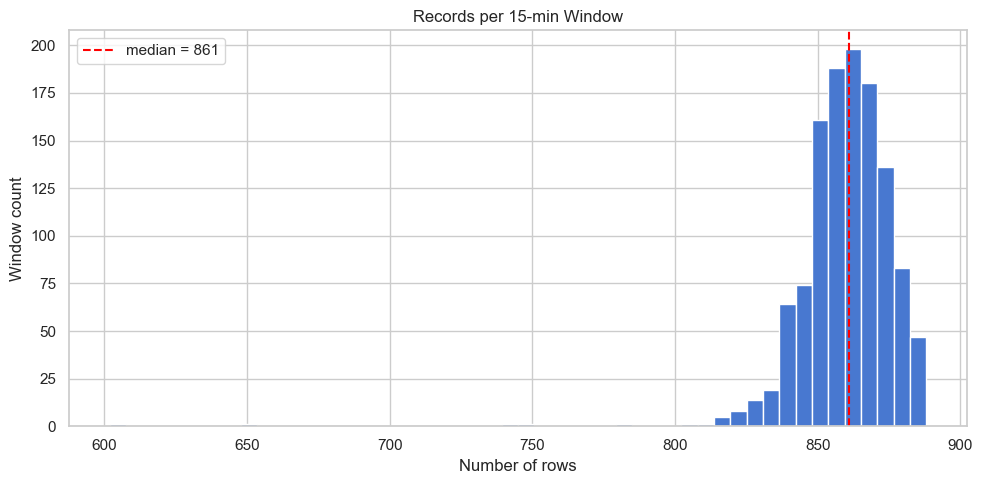

count    1184.000000
mean      859.650338
std        17.226139
min       602.000000
25%       852.000000
50%       861.000000
75%       870.000000
max       888.000000
dtype: float64


In [12]:
n_windows = df['open_time'].nunique()
date_min = df['curr_time'].min()
date_max = df['curr_time'].max()
print(f'Unique 15-min windows (open_time): {n_windows:,}')
print(f'Date range: {date_min} → {date_max}')

records_per_window = df.groupby('open_time').size()
fig, ax = plt.subplots(figsize=(10, 5))
records_per_window.hist(bins=50, ax=ax, edgecolor='white')
ax.set_title('Records per 15-min Window')
ax.set_xlabel('Number of rows')
ax.set_ylabel('Window count')
ax.axvline(records_per_window.median(), color='red', ls='--', label=f'median = {records_per_window.median():.0f}')
ax.legend()
plt.tight_layout()
plt.show()

print(records_per_window.describe())

---
## 2. Target Analysis

### Distribution of `next_price_dollars_lead1` and `outcome`

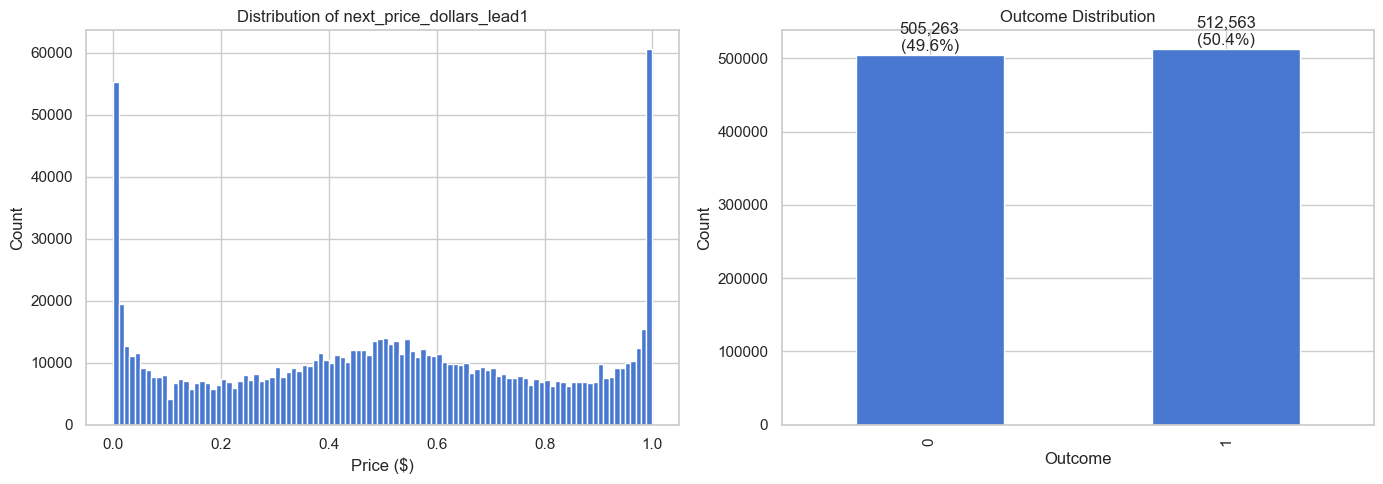

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df['next_price_dollars_lead1'].hist(bins=100, ax=axes[0], edgecolor='white')
axes[0].set_title('Distribution of next_price_dollars_lead1')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Count')

outcome_counts = df['outcome'].value_counts().sort_index()
outcome_counts.plot.bar(ax=axes[1], edgecolor='white')
axes[1].set_title('Outcome Distribution')
axes[1].set_xlabel('Outcome')
axes[1].set_ylabel('Count')
for i, v in enumerate(outcome_counts.values):
    axes[1].text(i, v + len(df)*0.005, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center')

plt.tight_layout()
plt.show()

### Δp = next_price − yes_mid

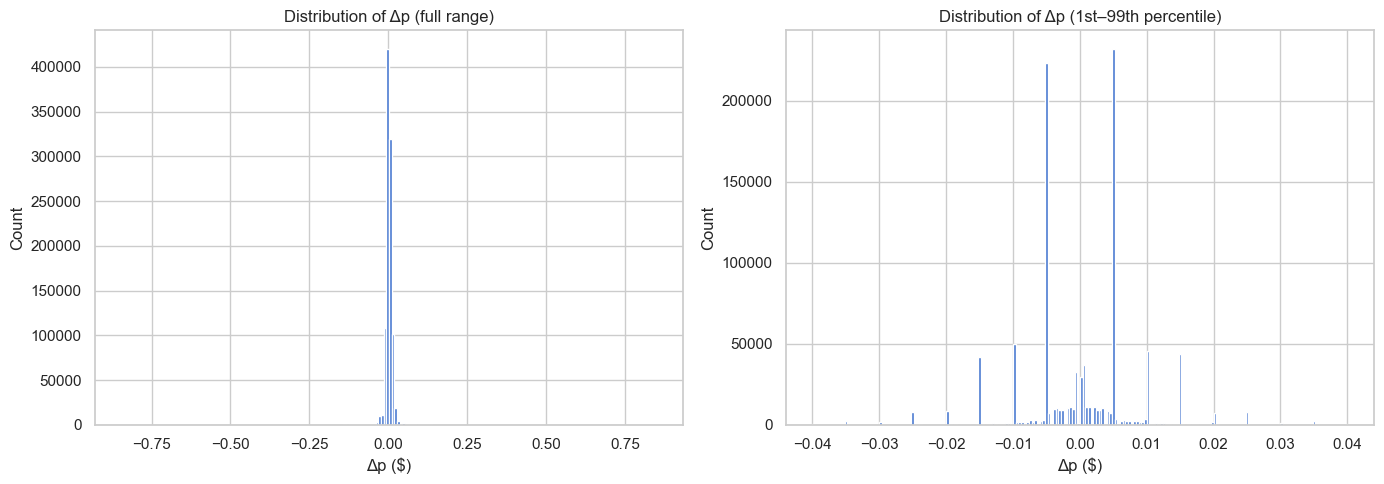

Skewness:  -4.3915
Kurtosis:  227.8550
Fraction Δp == 0: 2.7289% (27,743 rows)
Mean Δp:   -0.000072
Std Δp:    0.021545


In [14]:
df['delta_p'] = df['next_price_dollars_lead1'] - df['yes_mid_dollars']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['delta_p'].dropna(), bins=200, edgecolor='white')
axes[0].set_title('Distribution of Δp (full range)')
axes[0].set_xlabel('Δp ($)')
axes[0].set_ylabel('Count')

trimmed = df['delta_p'].dropna()
q01, q99 = trimmed.quantile(0.01), trimmed.quantile(0.99)
trimmed_inner = trimmed[(trimmed >= q01) & (trimmed <= q99)]
axes[1].hist(trimmed_inner, bins=200, edgecolor='white')
axes[1].set_title('Distribution of Δp (1st–99th percentile)')
axes[1].set_xlabel('Δp ($)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

dp = df['delta_p'].dropna()
print(f'Skewness:  {dp.skew():.4f}')
print(f'Kurtosis:  {dp.kurtosis():.4f}')
print(f'Fraction Δp == 0: {(dp == 0).mean():.4%} ({(dp == 0).sum():,} rows)')
print(f'Mean Δp:   {dp.mean():.6f}')
print(f'Std Δp:    {dp.std():.6f}')

### Directional accuracy baseline

Two naive predictors:
1. **No-change** — predict Δp = 0 → "correct" whenever actual Δp == 0.
2. **Momentum** — predict sign(Δp) = sign(yes_mid_change_1s).

In [15]:
mask = df['delta_p'].notna() & (df['delta_p'] != 0)
subset = df.loc[mask].copy()

no_change_acc = (df['delta_p'] == 0).mean()
print(f'No-change baseline accuracy (Δp==0): {no_change_acc:.4%}')

momentum_correct = (np.sign(subset['delta_p']) == np.sign(subset['yes_mid_change_1s']))
momentum_acc = momentum_correct.mean()
print(f'Momentum baseline (sign match, excluding Δp==0): {momentum_acc:.4%}')
print(f'  → rows evaluated: {len(subset):,} / {len(df):,}')

No-change baseline accuracy (Δp==0): 2.7257%
Momentum baseline (sign match, excluding Δp==0): 1.4141%
  → rows evaluated: 988,902 / 1,017,826


---
## 3. Feature Distributions

### Histograms / KDE for key features

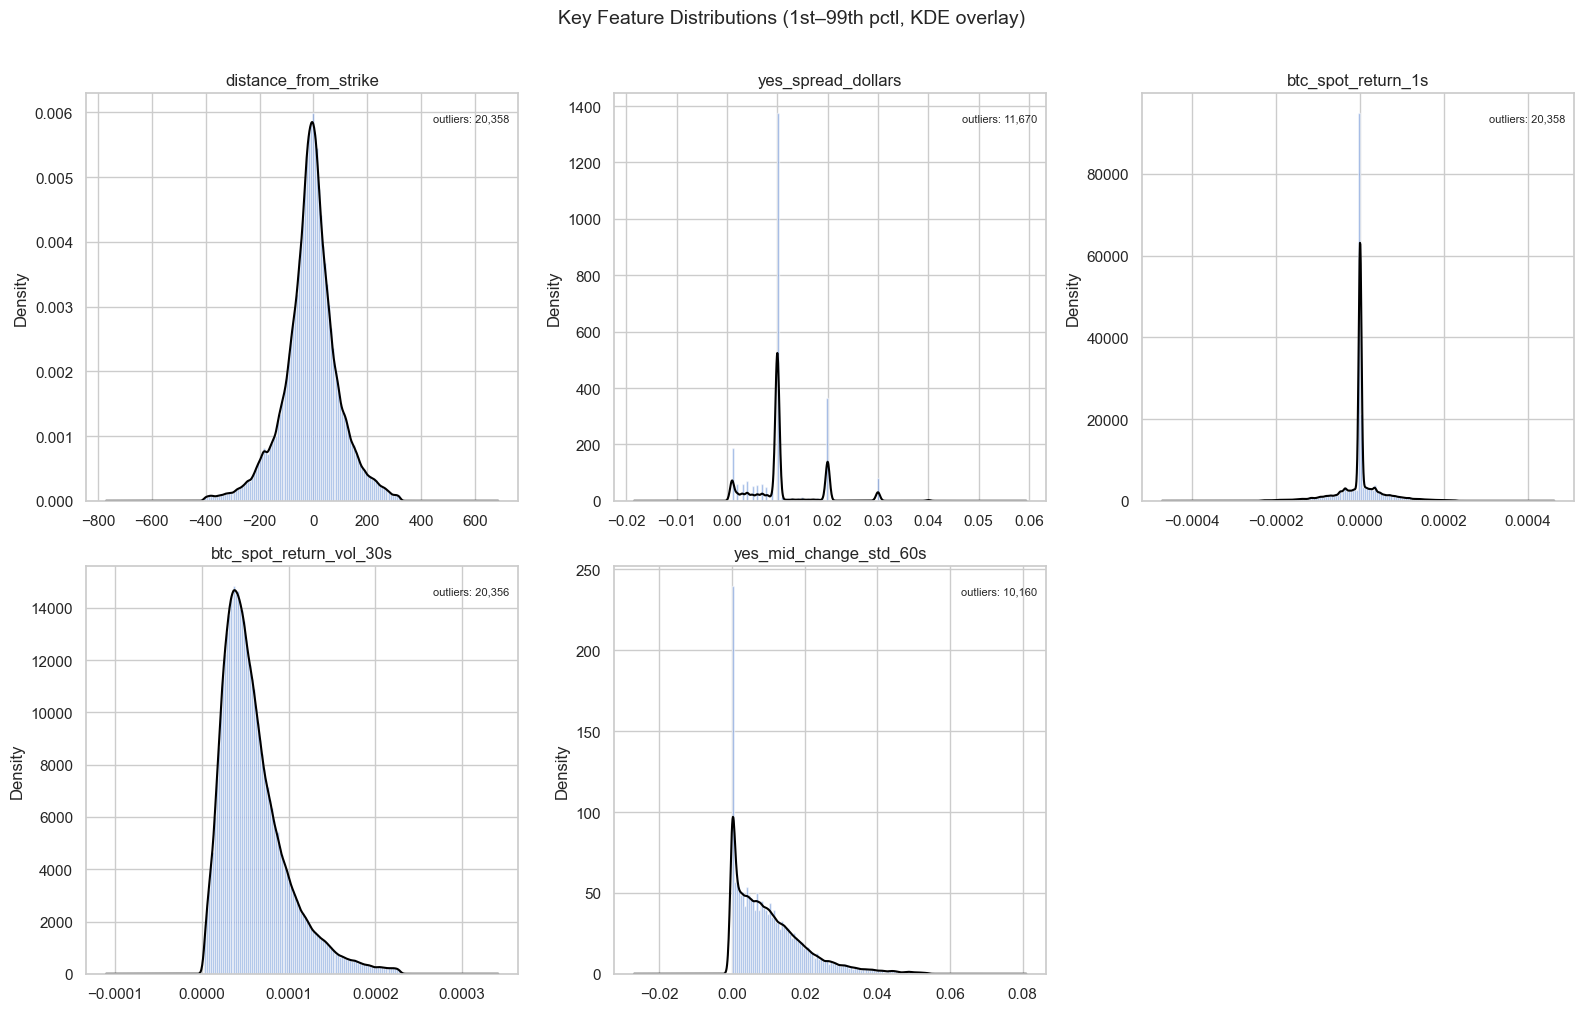

In [16]:
key_features = [
    'distance_from_strike', 'yes_spread_dollars',
    'btc_spot_return_1s', 'btc_spot_return_vol_30s',
    'yes_mid_change_std_60s',
]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    ax = axes[i]
    series = df[col].dropna()
    q01, q99 = series.quantile(0.01), series.quantile(0.99)
    clipped = series[(series >= q01) & (series <= q99)]
    ax.hist(clipped, bins=100, density=True, alpha=0.6, edgecolor='white')
    try:
        clipped.plot.kde(ax=ax, color='black', lw=1.5)
    except Exception:
        pass
    ax.set_title(col)
    ax.set_ylabel('Density')

    n_outliers_lo = (series < q01).sum()
    n_outliers_hi = (series > q99).sum()
    ax.annotate(f'outliers: {n_outliers_lo + n_outliers_hi:,}',
                xy=(0.98, 0.95), xycoords='axes fraction', ha='right', va='top', fontsize=8)

axes[-1].set_visible(False)
plt.suptitle('Key Feature Distributions (1st–99th pctl, KDE overlay)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### Box plots by outcome

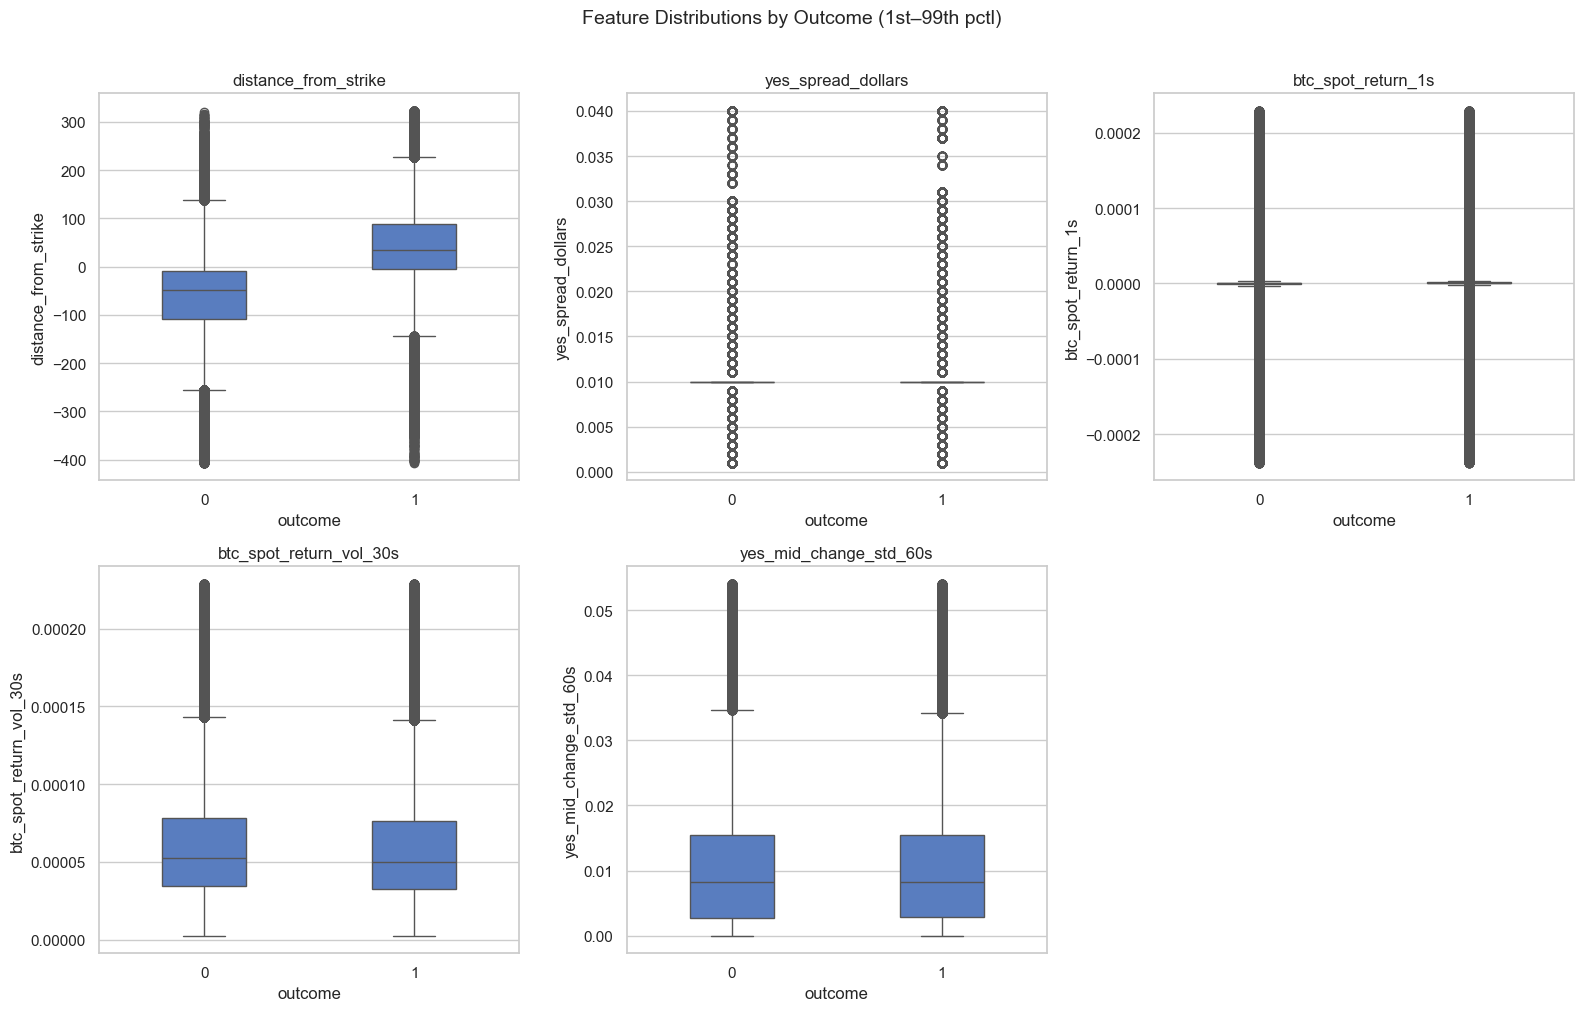

In [17]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(key_features):
    ax = axes[i]
    series = df[[col, 'outcome']].dropna()
    q01, q99 = series[col].quantile(0.01), series[col].quantile(0.99)
    series = series[(series[col] >= q01) & (series[col] <= q99)]
    sns.boxplot(data=series, x='outcome', y=col, ax=ax, width=0.4)
    ax.set_title(col)

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions by Outcome (1st–99th pctl)', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

---
## 4. Correlation Analysis

In [18]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
corr_with_dp = df[numeric_cols].corrwith(df['delta_p']).dropna().sort_values(key=abs, ascending=False)

print('Top 15 features by |correlation| with Δp:')
display(corr_with_dp.head(15).to_frame('corr_with_delta_p'))

Top 15 features by |correlation| with Δp:


,corr_with_delta_p
delta_p,1.000000
yes_spread_dollars,-0.075470
yes_spread_mean_30s,-0.060359
btc_spot_return_60s,0.041707
yes_mid_dollars,-0.038033
ETH_yes_mid_change_5s,0.033905
next_price_dollars_lead1,0.031512
yes_mid_change_1s,-0.029531
btc_spot_return_15s,0.028933
yes_mid_change_5s,-0.027923


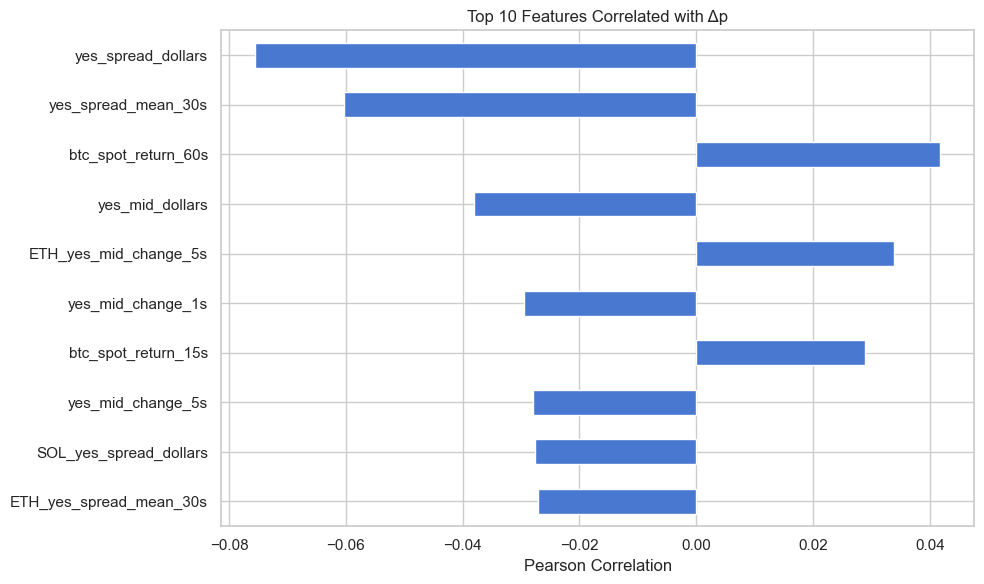

In [19]:
top10_features = corr_with_dp.drop(labels=['delta_p', 'next_price_dollars_lead1'], errors='ignore').head(10)

fig, ax = plt.subplots(figsize=(10, 6))
top10_features.plot.barh(ax=ax)
ax.set_title('Top 10 Features Correlated with Δp')
ax.set_xlabel('Pearson Correlation')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Correlation heatmap

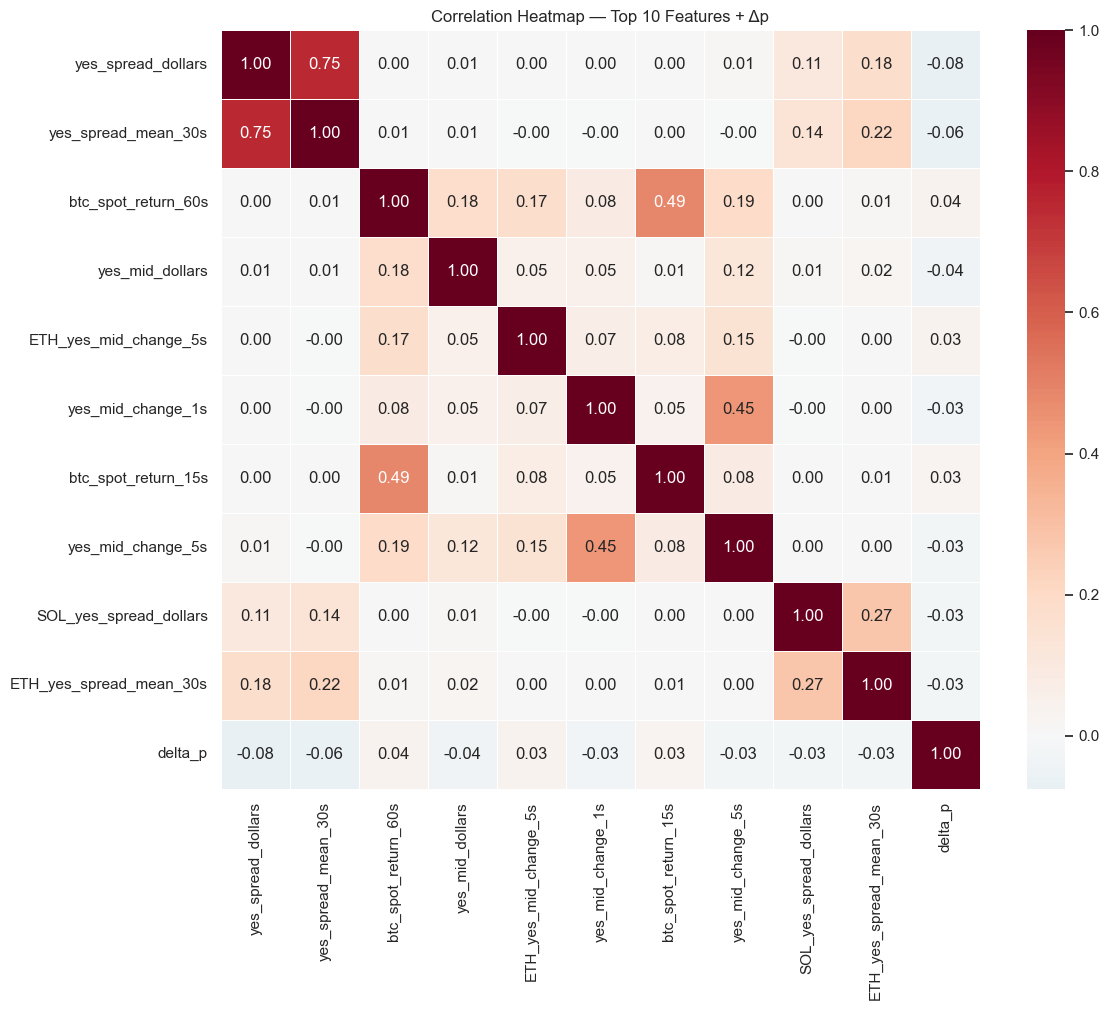

In [20]:
heatmap_cols = top10_features.index.tolist() + ['delta_p']
corr_matrix = df[heatmap_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap — Top 10 Features + Δp')
plt.tight_layout()
plt.show()

### Scatter plots — top 3 features vs Δp

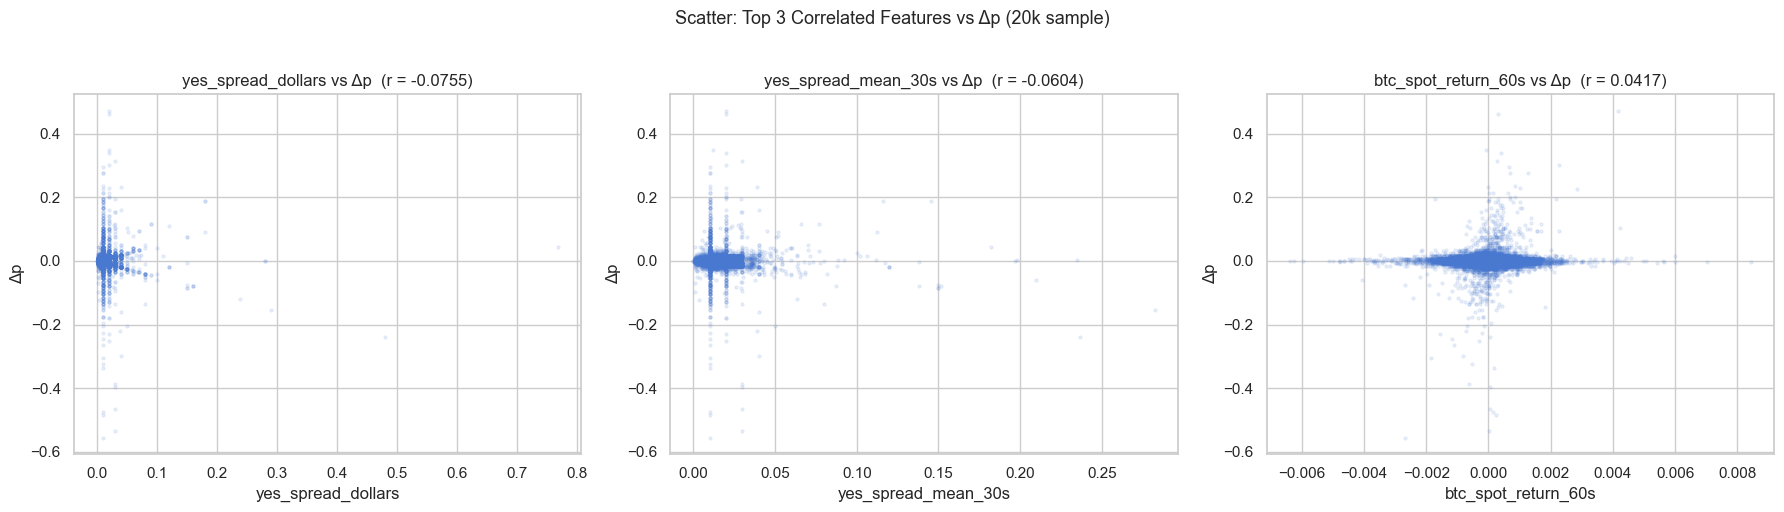

In [21]:
top3 = top10_features.head(3).index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sample = df.sample(min(20_000, len(df)), random_state=42)

for ax, col in zip(axes, top3):
    ax.scatter(sample[col], sample['delta_p'], alpha=0.1, s=5)
    ax.set_xlabel(col)
    ax.set_ylabel('Δp')
    r = df[[col, 'delta_p']].dropna().corr().iloc[0, 1]
    ax.set_title(f'{col} vs Δp  (r = {r:.4f})')

plt.suptitle('Scatter: Top 3 Correlated Features vs Δp (20k sample)', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

---
## 5. Cross-Coin Analysis

### BTC vs ETH / XRP / SOL — same-feature comparison

In [22]:
coins = ['ETH', 'XRP', 'SOL']
btc_features = [
    'yes_mid_dollars', 'yes_spread_dollars', 'distance_from_strike',
    'yes_mid_change_1s', 'yes_mid_change_5s',
    'yes_mid_change_std_30s', 'yes_mid_change_std_60s', 'yes_spread_mean_30s',
]

cross_corr_rows = []
for feat in btc_features:
    row = {'feature': feat}
    for coin in coins:
        coin_col = f'{coin}_{feat}'
        if coin_col in df.columns:
            row[f'BTC↔{coin}'] = df[[feat, coin_col]].dropna().corr().iloc[0, 1]
    cross_corr_rows.append(row)

cross_corr_df = pd.DataFrame(cross_corr_rows).set_index('feature')
print('Cross-coin correlation (BTC feature vs same feature for other coins):')
display(cross_corr_df.round(4))

Cross-coin correlation (BTC feature vs same feature for other coins):


,BTC↔ETH,BTC↔XRP,BTC↔SOL
feature,,,
yes_mid_dollars,0.8363,0.6906,0.7688
yes_spread_dollars,0.1649,0.0970,0.1064
distance_from_strike,0.9215,0.8495,0.8834
yes_mid_change_1s,0.0499,0.0130,0.0127
yes_mid_change_5s,0.1502,0.0697,0.0824
yes_mid_change_std_30s,0.4043,0.2620,0.3267
yes_mid_change_std_60s,0.5164,0.3595,0.4370
yes_spread_mean_30s,0.2152,0.1222,0.1347


### Cross-coin `yes_mid_change_1s` correlation matrix

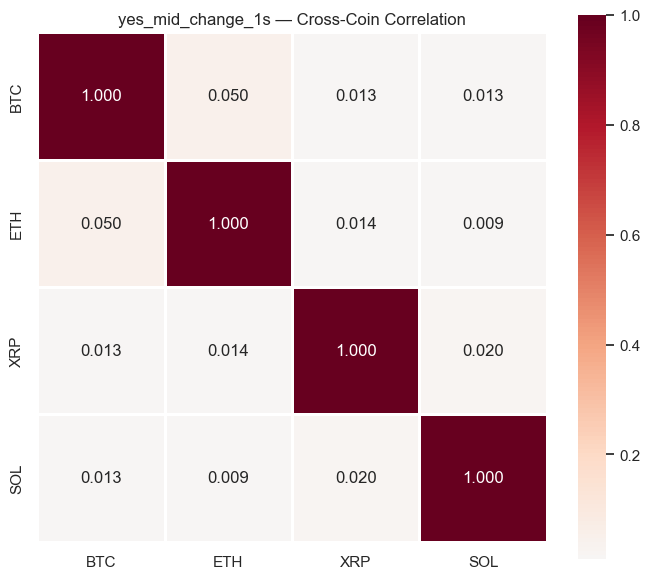

In [23]:
mid_1s_cols = ['yes_mid_change_1s'] + [f'{c}_yes_mid_change_1s' for c in coins]
mid_1s_labels = ['BTC'] + coins

corr_mid1s = df[mid_1s_cols].corr()
corr_mid1s.index = mid_1s_labels
corr_mid1s.columns = mid_1s_labels

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_mid1s, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, ax=ax, linewidths=1)
ax.set_title('yes_mid_change_1s — Cross-Coin Correlation')
plt.tight_layout()
plt.show()

### Cross-coin features ranked by correlation with Δp

Cross-coin features most correlated with BTC Δp:


,corr_with_delta_p
ETH_yes_mid_change_5s,0.0339
SOL_yes_spread_dollars,-0.0276
ETH_yes_spread_mean_30s,-0.0272
SOL_yes_spread_mean_30s,-0.0251
XRP_yes_mid_change_5s,0.0244
ETH_yes_spread_dollars,-0.0211
XRP_yes_spread_mean_30s,-0.0161
ETH_yes_mid_change_1s,0.0133
ETH_yes_mid_dollars,-0.0123
XRP_yes_mid_dollars,-0.0121


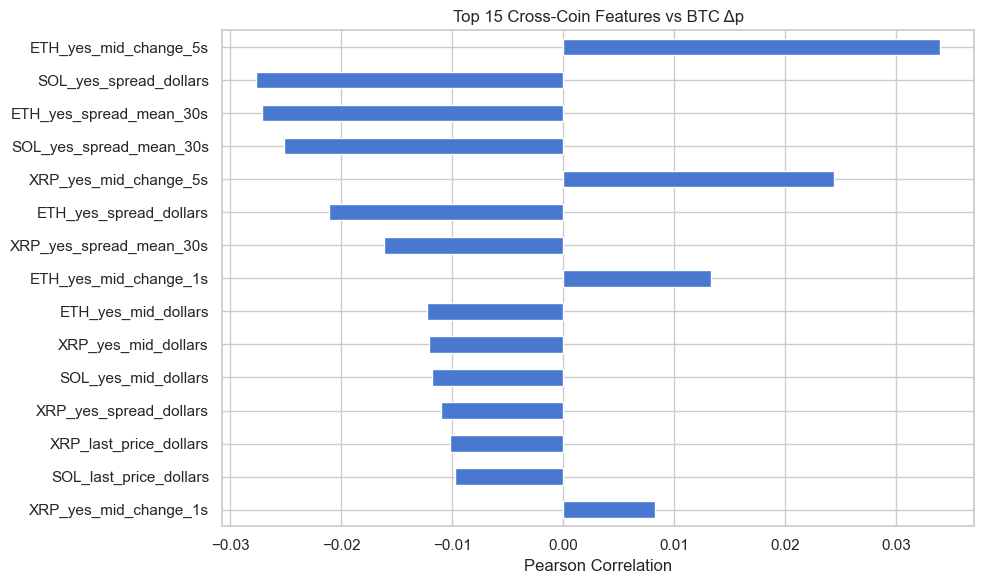

In [24]:
cross_coin_cols = [c for c in df.columns if any(c.startswith(f'{coin}_') for coin in coins)]
cross_corr_dp = df[cross_coin_cols].corrwith(df['delta_p']).dropna().sort_values(key=abs, ascending=False)

print('Cross-coin features most correlated with BTC Δp:')
display(cross_corr_dp.head(15).to_frame('corr_with_delta_p').round(4))

fig, ax = plt.subplots(figsize=(10, 6))
cross_corr_dp.head(15).plot.barh(ax=ax)
ax.set_title('Top 15 Cross-Coin Features vs BTC Δp')
ax.set_xlabel('Pearson Correlation')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 6. Temporal Patterns

### Intra-window dynamics — sample window

Sample window: 2026-03-24 04:30:00+00:00  (888 rows)


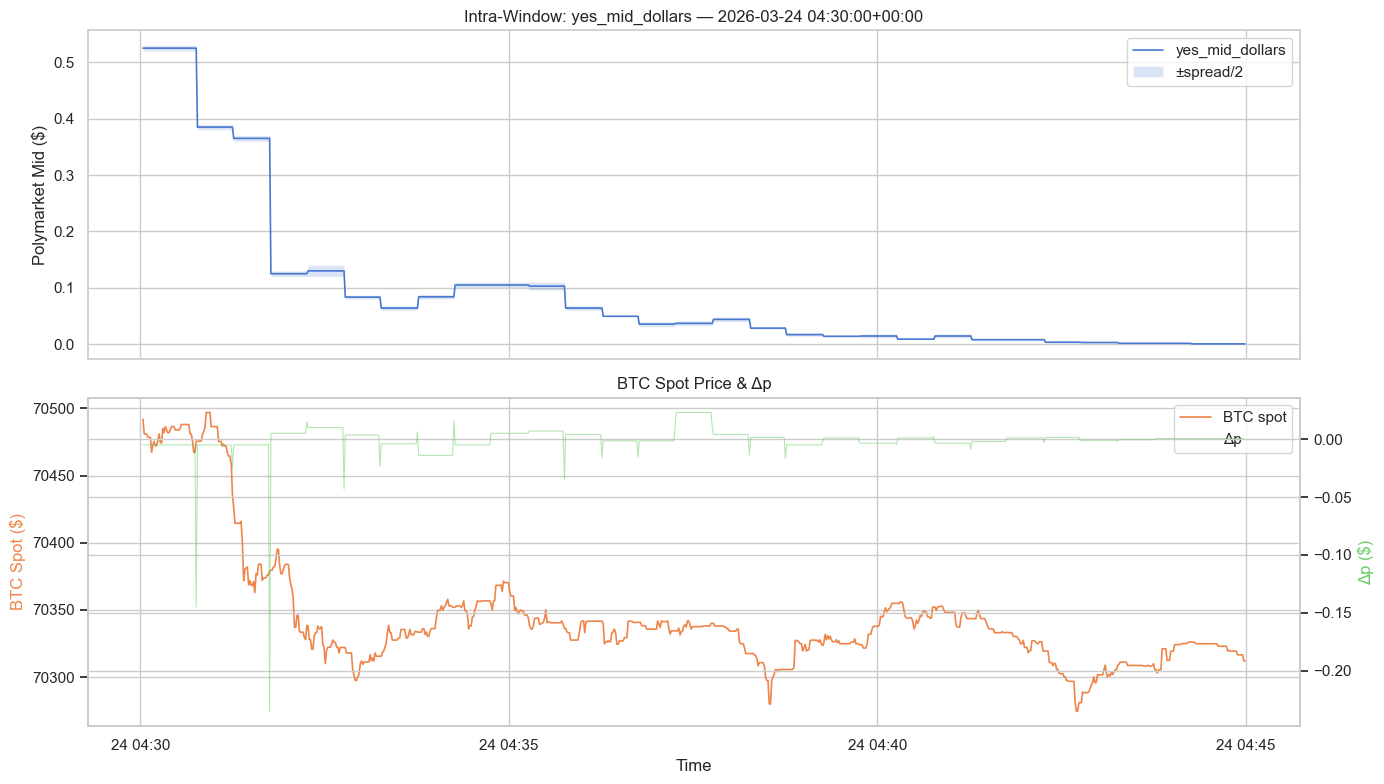

In [25]:
window_sizes = df.groupby('open_time').size()
sample_window = window_sizes.idxmax()

wdf = df[df['open_time'] == sample_window].sort_values('curr_time').copy()
print(f'Sample window: {sample_window}  ({len(wdf):,} rows)')

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(wdf['curr_time'], wdf['yes_mid_dollars'], label='yes_mid_dollars', lw=1.2)
axes[0].fill_between(wdf['curr_time'],
                      wdf['yes_mid_dollars'] - wdf['yes_spread_dollars']/2,
                      wdf['yes_mid_dollars'] + wdf['yes_spread_dollars']/2,
                      alpha=0.2, label='±spread/2')
axes[0].set_ylabel('Polymarket Mid ($)')
axes[0].set_title(f'Intra-Window: yes_mid_dollars — {sample_window}')
axes[0].legend()

ax1_twin = axes[1].twinx()
axes[1].plot(wdf['curr_time'], wdf['btc_spot_price'], color='C1', lw=1.2, label='BTC spot')
axes[1].set_ylabel('BTC Spot ($)', color='C1')
ax1_twin.plot(wdf['curr_time'], wdf['delta_p'], color='C2', alpha=0.5, lw=0.8, label='Δp')
ax1_twin.set_ylabel('Δp ($)', color='C2')
axes[1].set_xlabel('Time')
axes[1].set_title('BTC Spot Price & Δp')

lines1, labels1 = axes[1].get_legend_handles_labels()
lines2, labels2 = ax1_twin.get_legend_handles_labels()
axes[1].legend(lines1 + lines2, labels1 + labels2)

plt.tight_layout()
plt.show()

### `time_to_close` vs spread and volatility

As expiry approaches we expect the bid-ask spread to tighten and mid-price volatility to increase (markets resolve).

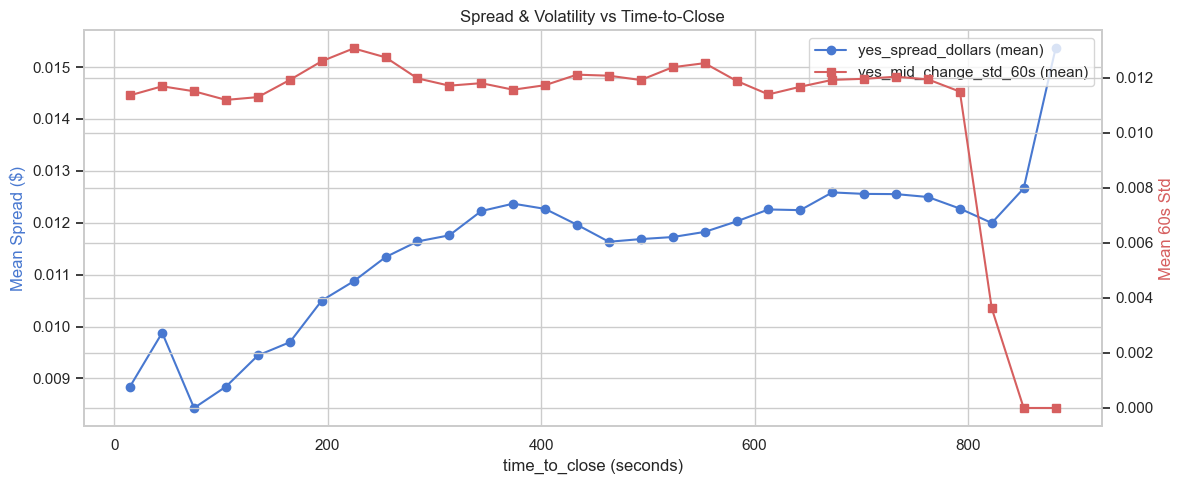

In [26]:
ttc_bins = pd.cut(df['time_to_close'], bins=30)
ttc_agg = df.groupby(ttc_bins, observed=True).agg(
    spread_mean=('yes_spread_dollars', 'mean'),
    vol60_mean=('yes_mid_change_std_60s', 'mean'),
).reset_index()
ttc_agg['ttc_mid'] = ttc_agg['time_to_close'].apply(lambda x: x.mid)

fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(ttc_agg['ttc_mid'], ttc_agg['spread_mean'], 'o-', color='C0', label='yes_spread_dollars (mean)')
ax2.plot(ttc_agg['ttc_mid'], ttc_agg['vol60_mean'], 's-', color='C3', label='yes_mid_change_std_60s (mean)')

ax1.set_xlabel('time_to_close (seconds)')
ax1.set_ylabel('Mean Spread ($)', color='C0')
ax2.set_ylabel('Mean 60s Std', color='C3')
ax1.set_title('Spread & Volatility vs Time-to-Close')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')

plt.tight_layout()
plt.show()

### Δp volatility by hour of day

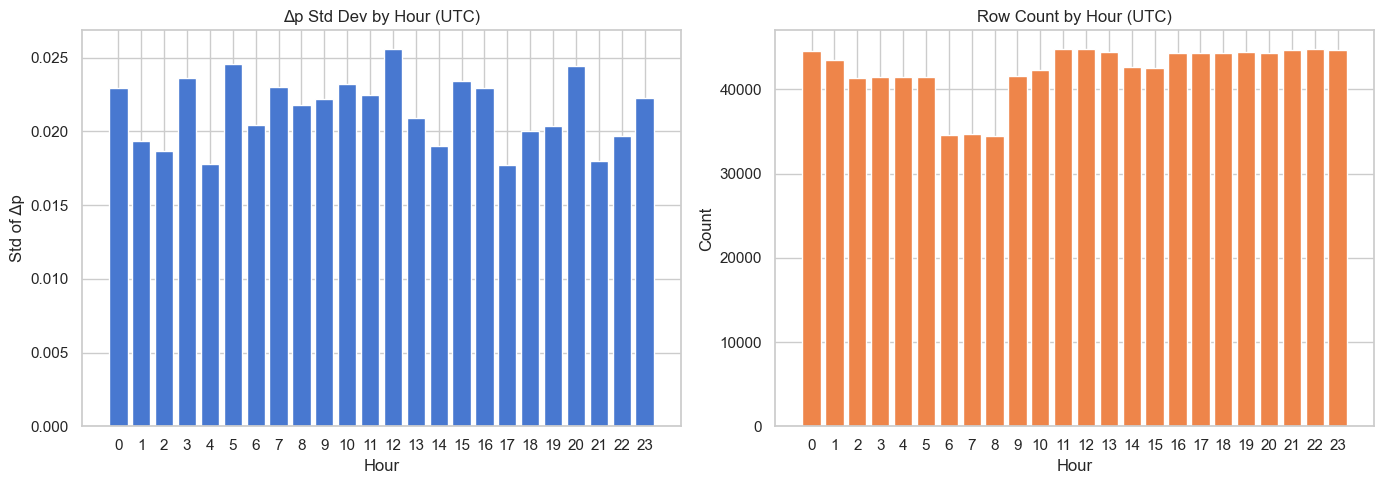

In [27]:
df['hour'] = df['curr_time'].dt.hour

hourly_vol = df.groupby('hour')['delta_p'].agg(['std', 'mean', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(hourly_vol.index, hourly_vol['std'], edgecolor='white')
axes[0].set_title('Δp Std Dev by Hour (UTC)')
axes[0].set_xlabel('Hour')
axes[0].set_ylabel('Std of Δp')
axes[0].set_xticks(range(24))

axes[1].bar(hourly_vol.index, hourly_vol['count'], color='C1', edgecolor='white')
axes[1].set_title('Row Count by Hour (UTC)')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Count')
axes[1].set_xticks(range(24))

plt.tight_layout()
plt.show()

---
## 7. Spot Market Signals

### `btc_spot_return_5s` and `btc_spot_signed_flow_mean_30s` vs Δp

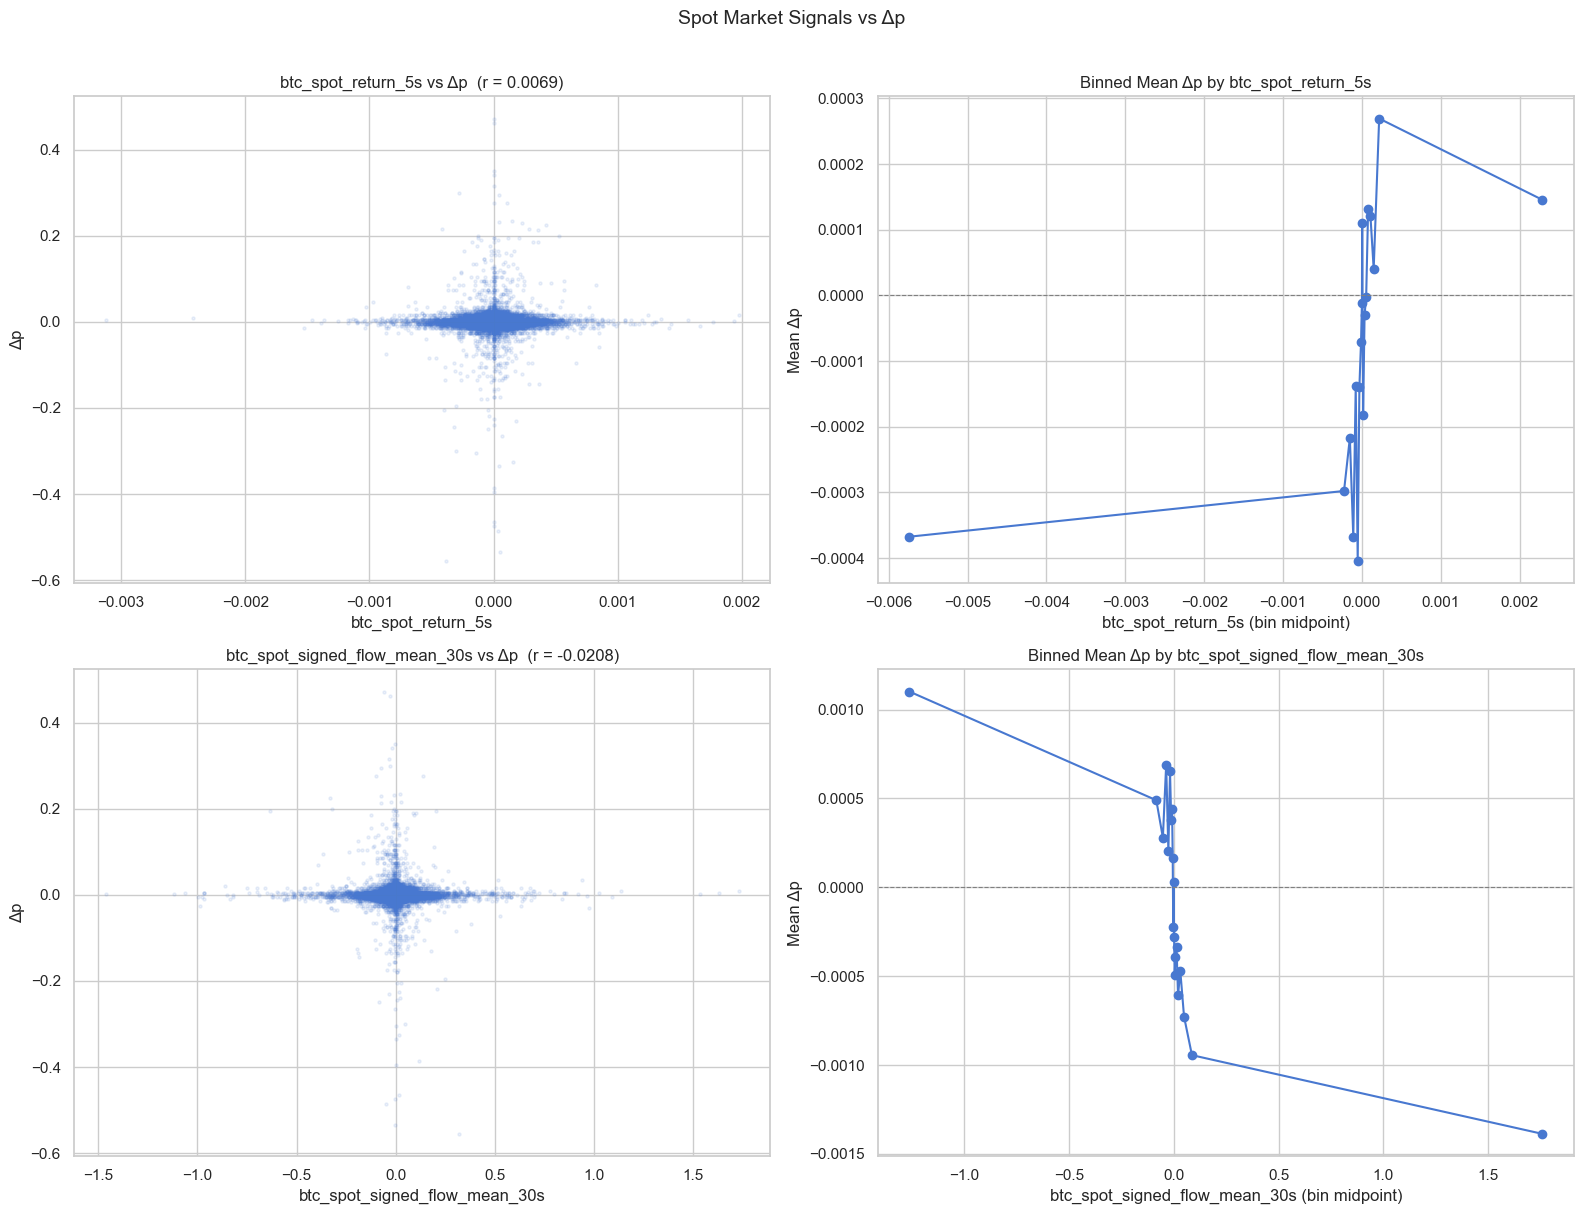

In [28]:
spot_features = ['btc_spot_return_5s', 'btc_spot_signed_flow_mean_30s']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

sample = df.sample(min(20_000, len(df)), random_state=42)

for i, col in enumerate(spot_features):
    ax_scat = axes[i, 0]
    ax_scat.scatter(sample[col], sample['delta_p'], alpha=0.1, s=5)
    r = df[[col, 'delta_p']].dropna().corr().iloc[0, 1]
    ax_scat.set_title(f'{col} vs Δp  (r = {r:.4f})')
    ax_scat.set_xlabel(col)
    ax_scat.set_ylabel('Δp')

    ax_bin = axes[i, 1]
    valid = df[[col, 'delta_p']].dropna()
    valid['bin'] = pd.qcut(valid[col], q=20, duplicates='drop')
    binned = valid.groupby('bin', observed=True)['delta_p'].mean()
    bin_mids = [interval.mid for interval in binned.index]
    ax_bin.plot(bin_mids, binned.values, 'o-')
    ax_bin.axhline(0, color='grey', ls='--', lw=0.8)
    ax_bin.set_title(f'Binned Mean Δp by {col}')
    ax_bin.set_xlabel(col + ' (bin midpoint)')
    ax_bin.set_ylabel('Mean Δp')

plt.suptitle('Spot Market Signals vs Δp', y=1.01, fontsize=14)
plt.tight_layout()
plt.show()

### Does `btc_spot_return_vol_30s` predict larger |Δp| moves?

Pearson correlation btc_spot_return_vol_30s ↔ |Δp|: 0.0019


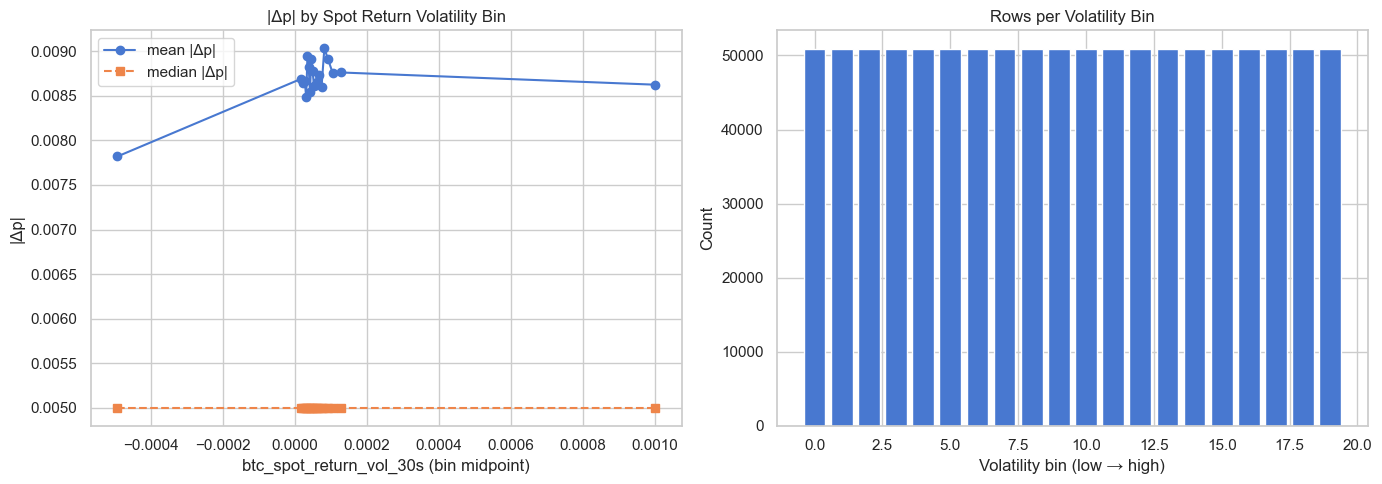

In [29]:
df['abs_delta_p'] = df['delta_p'].abs()

valid = df[['btc_spot_return_vol_30s', 'abs_delta_p']].dropna()
valid['vol_bin'] = pd.qcut(valid['btc_spot_return_vol_30s'], q=20, duplicates='drop')
binned = valid.groupby('vol_bin', observed=True)['abs_delta_p'].agg(['mean', 'median', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bin_mids = [interval.mid for interval in binned.index]
axes[0].plot(bin_mids, binned['mean'], 'o-', label='mean |Δp|')
axes[0].plot(bin_mids, binned['median'], 's--', label='median |Δp|')
axes[0].set_xlabel('btc_spot_return_vol_30s (bin midpoint)')
axes[0].set_ylabel('|Δp|')
axes[0].set_title('|Δp| by Spot Return Volatility Bin')
axes[0].legend()

axes[1].bar(range(len(binned)), binned['count'], edgecolor='white')
axes[1].set_xlabel('Volatility bin (low → high)')
axes[1].set_ylabel('Count')
axes[1].set_title('Rows per Volatility Bin')

r = df[['btc_spot_return_vol_30s', 'abs_delta_p']].dropna().corr().iloc[0, 1]
print(f'Pearson correlation btc_spot_return_vol_30s ↔ |Δp|: {r:.4f}')

plt.tight_layout()
plt.show()

---
## 8. Key Takeaways

*Fill in after reviewing all outputs above.*

### (a) Data Quality
- **Missing / Inf values**: document counts above.
- **Rows per window**: check whether any windows are very thin (few rows) — may need filtering.
- **Outliers**: several features are heavy-tailed; clipping or robust scaling recommended.

### (b) Most Predictive Features
- Review the top-10 correlation bar chart. Even small linear correlations matter at ~1M rows.
- Note which features survive as top correlated after accounting for autocorrelation within windows.

### (c) Cross-Coin Signal
- If cross-coin features appear in the top-15 for Δp correlation, there is evidence that parallel market movements in ETH/XRP/SOL carry predictive information for BTC.
- The `yes_mid_change_1s` cross-coin matrix reveals how synchronized 1-second moves are across coins.

### (d) Temporal Structure
- **Time-to-close effects**: spreads and volatility should vary — confirm whether the market tightens near expiry.
- **Hour-of-day**: some hours may be noisier (higher Δp std), which can inform train/test splits or time-aware features.
- Intra-window dynamics suggest sequential structure → potential benefit from LSTM / sequence models.

### (e) Modeling Implications
- **High fraction of Δp==0**: the target is heavily zero-inflated — may need a two-stage model (classify move vs no-move, then predict direction/magnitude).
- **Nonlinear patterns**: if scatter plots show threshold effects (e.g., Δp responds only when btc_spot_return_vol_30s exceeds a level), tree-based models (XGBoost) or interaction terms in linear models will help.
- **Autocorrelation within windows**: standard cross-validation will leak. Use grouped (by window) splits.
- **Feature scaling**: Ridge/Lasso need standardization; XGBoost does not.

In [30]:
df.drop(columns=['delta_p', 'abs_delta_p', 'hour'], inplace=True, errors='ignore')
print('Temporary columns cleaned up.')

Temporary columns cleaned up.
